# How well does mean tumor radius predict mean concavity?

Correlation and simple linear regression on the Breast Cancer Wisconsin (Diagnostic) dataset, with residual diagnostics.

## Load the data

In [1]:
import pandas as pd
df = pd.read_csv("data/breast-cancer-wisconsin.csv")
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


## Summary statistics

In [2]:
# descriptive stats functions, written from scratch
def my_mean(data):
    sumtotal = 0
    n = len(data)
    for element in data:
        sumtotal += element
    return sumtotal/n

def my_median(data):
    sorted_data = sorted(data) # sort data so median works for unsorted input
    n = len(sorted_data) # substitute 'data' with 'sorted_data'
    if n % 2 == 1:
        return sorted_data[n//2]
    else:
        middle_1, middle_2 = n//2 - 1, n//2
        return (sorted_data[middle_1] + sorted_data[middle_2]) / 2

def my_count(data, item):
    occurences = 0
    for element in data:
        if element == item:
            occurences += 1
    return occurences

def my_mode(data): # handling case with all unique values and no mode
    appearances = {} # add dictionary to store appearances of unique values
    for element in data:
        appearances[element] = appearances.get(element, 0) + 1
    max_appearances = max(appearances.values())
    modes = [k for k, v in appearances.items() if v == max_appearances]
    if len(modes) == len(appearances):
        return "No mode" # return 'no mode' if all values appear equally often
    elif len(modes) == 1:
        return modes[0] # return the mode
    else:
        return modes # return list of modes

def my_sample_SD(data):
    n = len(data)
    if n < 2: # avoiding zero divission error
        return 0
    sum_of_squares = 0
    mean = my_mean(data)
    for element in data:
        sum_of_squares += (element - mean)**2
    return (sum_of_squares/(n-1))**0.5

def my_range(data):
    sorted_data = sorted(data) # sort data for correct range calculation
    return sorted_data[-1] - sorted_data[0]

In [3]:
# call the functions and print the stats
radius_mean = df['radius_mean']
concavity_mean = df['concavity_mean']

data = {
    'Stats': ['count', 'mean', 'median', 'mode', 'SD', 'range'],
    'Radius': [len(radius_mean), round(my_mean(radius_mean), 4), round(my_median(radius_mean), 4), my_mode(radius_mean), round(my_sample_SD(radius_mean),4), round(my_range(radius_mean),4)],
    'Concavity': [len(concavity_mean), round(my_mean(concavity_mean), 4), round(my_median(concavity_mean), 4), my_mode(concavity_mean), round(my_sample_SD(concavity_mean),4),round(my_range(concavity_mean),4)]
}
dataa = pd.DataFrame(data)
print(dataa)

    Stats    Radius  Concavity
0   count  569.0000   569.0000
1    mean   14.1273     0.0888
2  median   13.3700     0.0615
3    mode   12.3400     0.0000
4      SD    3.5240     0.0797
5   range   21.1290     0.4268


## Distribution graphs for main variables

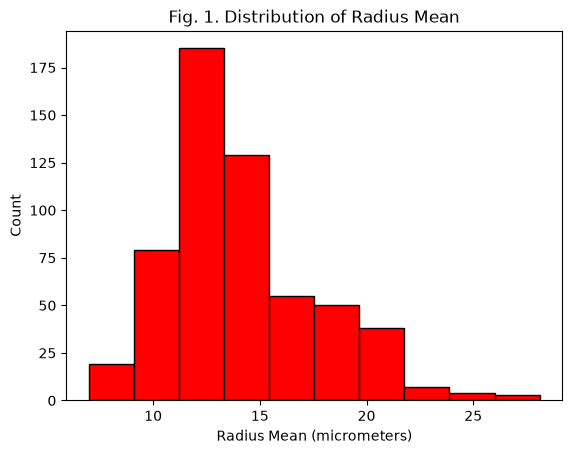

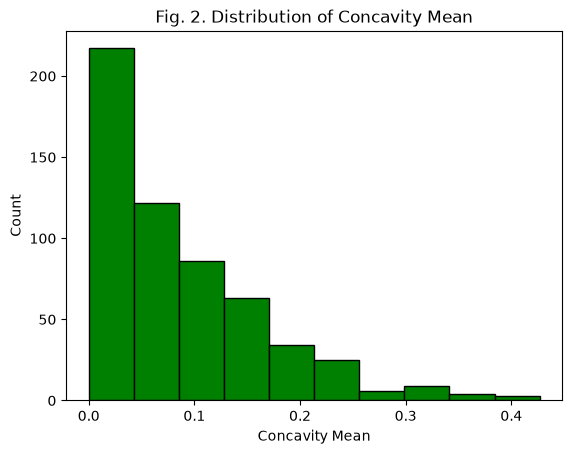

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(radius_mean, edgecolor="black", color="red")
plt.xlabel('Radius Mean (micrometers)')
plt.ylabel('Count')
plt.title('Fig. 1. Distribution of Radius Mean')
plt.show()

plt.figure()
plt.hist(concavity_mean, edgecolor="black", color="green")
plt.xlabel('Concavity Mean')
plt.ylabel('Count')
plt.title('Fig. 2. Distribution of Concavity Mean')
plt.show()

## Calculating Pearson's r

In [5]:
# calculating Pearson's r
from scipy.stats import pearsonr
corr, _ = pearsonr(radius_mean, concavity_mean)
print(corr)

0.6767635503908116


## Building the regression model, with plots for model validation

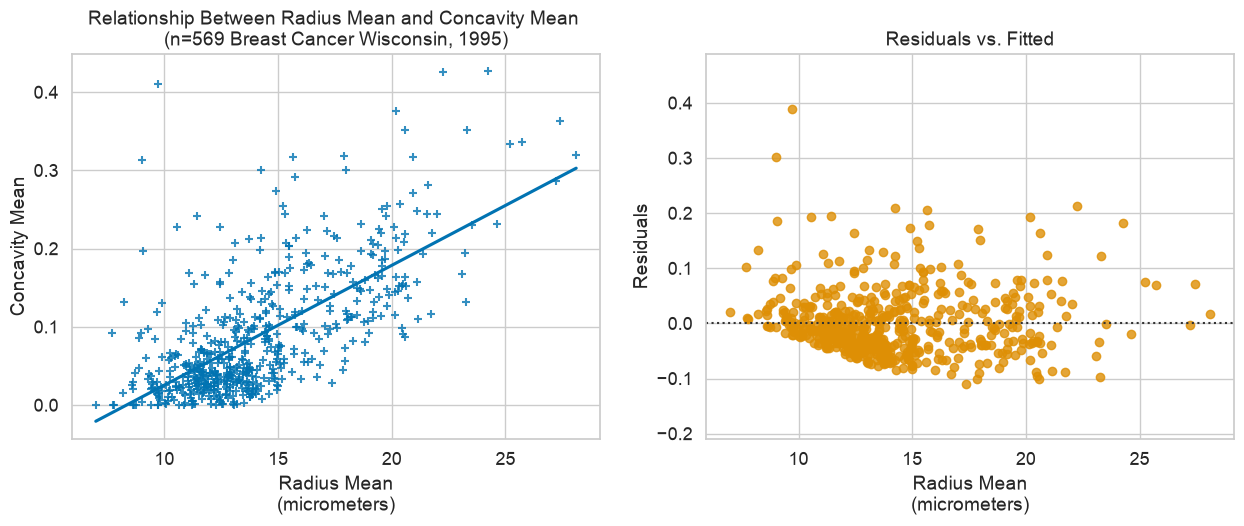

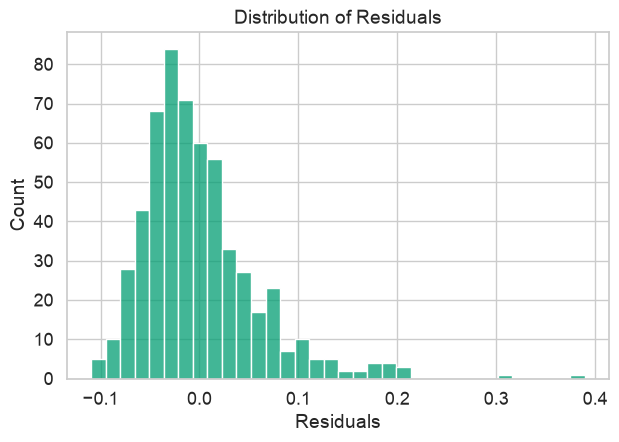

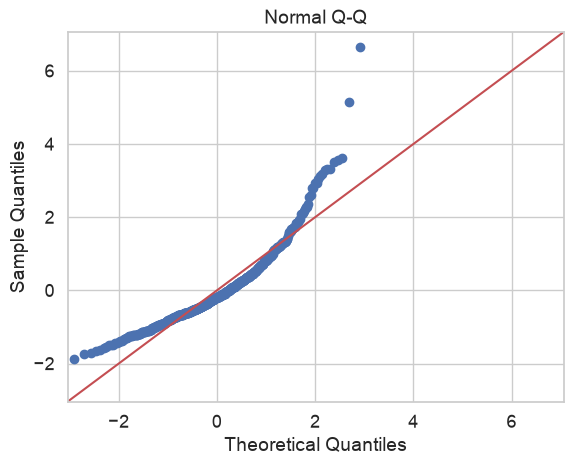

R-squared =  0.458
Regression equation: concavity_mean =  0.015 * radius_mean +  -0.127 



In [6]:
import pandas
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as statsmodels # useful stats package with regression functions
import seaborn as sns # very nice plotting package

# style settings
sns.set(color_codes=True, font_scale = 1.15)
sns.set_style("whitegrid")
colors = sns.color_palette('colorblind')

def regression_model(data, column_x, column_y):
    # this function uses built in library functions to create a scatter plot,
    # plots of the residuals, compute R-squared, and display the regression eqn

    # fit the regression line using "statsmodels" library:
    X = statsmodels.add_constant(data[column_x])
    Y = data[column_y]
    regressionmodel = statsmodels.OLS(Y,X).fit() # OLS = ordinary least squares

    # extract regression parameters from model, rounded to 3 decimal places:
    Rsquared = round(regressionmodel.rsquared,3)
    slope = round(regressionmodel.params.iloc[1],3)
    intercept = round(regressionmodel.params.iloc[0],3)

    # MAKE PLOTS:
    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, figsize=(15,5))

    # scatter plot
    sns.regplot(x=column_x, y=column_y, data=data, marker="+", ax=ax1, color=colors[0], ci=None)
    ax1.set_title("Relationship Between Radius Mean and Concavity Mean \n(n=569 Breast Cancer Wisconsin, 1995)")
    ax1.set(ylabel="Concavity Mean")
    ax1.set(xlabel="Radius Mean" + "\n(micrometers)")

    # residual scatter plot
    sns.residplot(x=column_x, y=column_y, data=data, ax=ax2, color=colors[1])
    ax2.set(ylabel='Residuals')
    ax2.set(xlabel="Radius Mean" + "\n(micrometers)")
    ax2.set_ylim(min(regressionmodel.resid)-0.1,max(regressionmodel.resid)+0.1)
    ax2.set_title("Residuals vs. Fitted")

    # residual histogram
    plt.figure(figsize=(7,4.5))
    sns.histplot(regressionmodel.resid, kde=False, color=colors[2])
    plt.ylabel("Count")
    plt.xlabel("Residuals")
    plt.title("Distribution of Residuals")

    # the Q-Q plot
    fig = statsmodels.qqplot(regressionmodel.resid, fit=True, line='45')
    plt.title("Normal Q-Q")
    plt.show()

    # print the results:
    print("R-squared = ",Rsquared)
    print("Regression equation: "+column_y+" = ",slope,"* "+column_x+" + ",intercept,"\n")

regression_model(df,"radius_mean","concavity_mean")

## Significance and confidence interval

In [7]:
def the_model(data, column_x, column_y):
    # define predictors X and response Y:
    import statsmodels.api as statsmodels
    X = data[column_x]
    X = statsmodels.add_constant(X) # Add a constant to the predictor (required by statsmodels for the intercept)
    Y = data[column_y]

    # construct model:
    global regressionmodel
    regressionmodel = statsmodels.OLS(Y,X).fit() # OLS = "ordinary least squares"

In [8]:
the_model(df,'radius_mean','concavity_mean')
print(regressionmodel.summary())
print("\n", "P-values \n", regressionmodel.pvalues)

                            OLS Regression Results                            
Dep. Variable:         concavity_mean   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     479.1
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.91e-77
Time:                        23:24:12   Log-Likelihood:                 806.52
No. Observations:                 569   AIC:                            -1609.
Df Residuals:                     567   BIC:                            -1600.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.1275      0.010    -12.519      